In [3]:
%load_ext autoreload
%autoreload 2
%pwd
%ls

 initializers/   log-aug-3.csv                memory_usage_lines.pdf
 layers/         log-aug-3-highsparsity.csv   memory_usage_lines.png
 log2.csv        log.csv                     'plots and stats.ipynb'
 log3.csv        log_mnist.csv                pruner_grower/


In [12]:
import pandas as pd
import numpy as np
import sys
from collections import defaultdict
sys.path.append("..")
from benchmark.plots.matrix_matrix import *

# df = pd.read_csv("log2.csv")
df = pd.read_csv("log-aug-3.csv")
df["sparsity_level"] =  df["sparsity_level"] * 100
if "isSparse" in df.columns:
    df["Type"] = df["isSparse"]

dense_level = list(df["dense_level"].unique())[7]

dfc = df[(df.dense_level == dense_level)&(df.sparsity_level.isin([ 90, 95, 99])) *(df.batch_size < 2)]
dfc = dfc.groupby(['Type', 'dense_level', 'sparsity_level', 'isSparse']).mean().reset_index()
dfc

,Type,dense_level,sparsity_level,isSparse,batch_size,cuda_elapsed_time,total_params,energy_spent_per_second,rep,energy_spent,average_power_used,average_utilization,average_memory_used,cuda_OOM
0,Dense (Only),12500x10000,90.0,Dense (Only),1.0,618.622986,125010000.0,0.000009,0.0,0.005577,100.389000,20.000000,6951.375,0.0
1,Dense (Only),12500x10000,95.0,Dense (Only),1.0,618.741760,125010000.0,0.000009,0.0,0.005603,100.862500,34.000000,3605.375,0.0
2,Dense (Only),12500x10000,99.0,Dense (Only),1.0,618.106873,125010000.0,0.000009,0.0,0.005281,95.053250,34.000000,6951.375,0.0
3,Dense+Mask,12500x10000,90.0,Dense+Mask,1.0,1358.272461,250010000.0,0.000012,0.0,0.015702,102.777273,70.909091,5995.375,0.0
4,Dense+Mask,12500x10000,95.0,Dense+Mask,1.0,1357.398071,250010000.0,0.000011,0.0,0.015108,98.890727,66.181818,6473.375,0.0
5,Dense+Mask,12500x10000,99.0,Dense+Mask,1.0,1358.286865,250010000.0,0.000012,0.0,0.015785,103.316818,66.909091,7429.375,0.0
6,Snack,12500x10000,90.0,Snack,1.0,163.119110,37509997.0,0.000009,0.0,0.001392,100.200000,0.000000,1863.000,NaN
7,Snack,12500x10000,95.0,Snack,1.0,82.992126,18760000.0,0.000019,0.0,0.001549,111.534000,2.000000,1023.000,NaN
8,Snack,12500x10000,99.0,Snack,1.0,45.321217,3760000.0,0.000033,0.0,0.001509,108.628000,0.000000,839.000,NaN


Code snippet of what I am measuring
```python

input_size = 20000
output_size = 10000
if type_ == 'Snack':

    model = Snack(input_size, output_size, sparsity=sparsity).cuda()
else:
    model = Dense(input_size, output_size).cuda()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# Dummy data
x = torch.randn(input_size).cuda()

start_event.record()
t1 = tic()
torch.cuda.synchronize()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
end_event.record()
```

/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/DST/../benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dlvl[col] = df_dlvl[col]  # .apply(lambda x: np.log2(x))
/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/DST/../benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dlvl[col] = df_dlvl[col]  # .apply(lambda x: np.log2(x))
/tmp/ipykernel_110314/3211277235.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

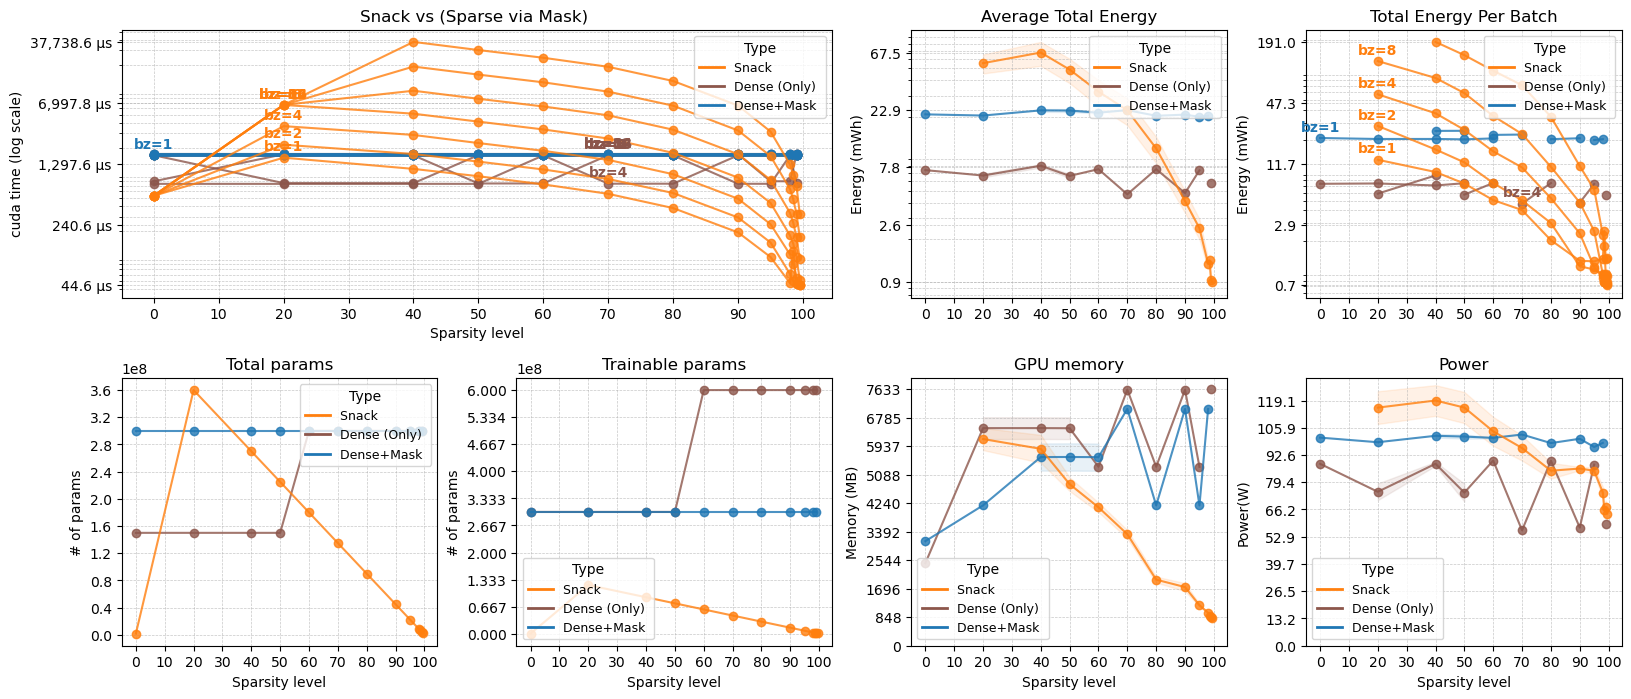

In [38]:
fig = plt.figure(figsize=(25, 8))
gs = fig.add_gridspec(2, 4)  # 2 rows, 2 columns
ax1 = fig.add_subplot(gs[0, :2])  # Spanning both columns

create_single_plot_for_batches(
    df, 
    
    dense_level, 
    "cuda_elapsed_time",
    [1 << i for i in range(0,7,1)],
    figsize=(6.75, 4), 
    log=True,
    title="Snack vs (Sparse via Mask) ",
    x_label="Sparsity level",
    y_label="cuda time (log scale)",
    batch_needed=True,
    ax=ax1
    
)
# fig.savefig("../figures/mask+dense-vs-snack-100-cuda-time-vs-batch.png", bbox_inches='tight')
ax2 = fig.add_subplot(gs[1, 0])  # Bottom left

dfc = df[df["batch_size"]==1]
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "total_params",
    [1 << i for i in range(10)],
    figsize=(4, 2), 
    log=False,
    title="Total params",
    x_label="Sparsity level",
    y_label="# of params",
    batch_needed=False,
    suffix="",
    ax=ax2
)
# axes[0, 1].remove() 
ax3 = fig.add_subplot(gs[1, 1])  # Bottom right

dfc["trainable_parameters"] = dfc["total_params"] * (
    np.ones_like(dfc["total_params"])-(dfc["Type"]=="Snack").astype(int)* 2./3 + (dfc["Type"]=="Dense (Only)").astype(int) * 1
)
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "trainable_parameters",
    [1 << i for i in range(10)],
    figsize=(4, 2), 
    log=False,
    title="Trainable params",
    x_label="Sparsity level",
    y_label="# of params",
    batch_needed=False,
    suffix="",
    legend_place="lower left",
    ax=ax3
    
)
plt.subplots_adjust(0.3)
plt.subplots_adjust(hspace=0.3)


# fig.suptitle("Snack vs Dense + Mask (simulating sparse layer)")
#plt.close(fig) from collections import defaultdict
axes = defaultdict(dict)
axes[0][2] = fig.add_subplot(gs[0, 2])
axes[1][2] = fig.add_subplot(gs[1, 2])
axes[0][3] = fig.add_subplot(gs[0, 3])
axes[1][3] = fig.add_subplot(gs[1, 3])

dfc = df.copy()
MAX_BATCH = 5

# create_single_plot_for_batches(
#     dfc, 
    
#     dense_level, 
#     "average_utilization",
#     [1 << i for i in range(0,MAX_BATCH,1)],
#     figsize=(6, 2), 
#     log=False,
#     title="Utilization",
#     x_label="",
#     y_label="Utilization % of GPU",
#     batch_needed=False,
#     ax=axes[0][0]
    
# )
dfc["energy_spent"] = dfc["energy_spent"] * 1000
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "energy_spent",
    [1 << i for i in range(0,MAX_BATCH)],
    figsize=(5, 2), 
    log=True,
    title="Total Energy Per Batch",
    x_label="",
    y_label="Energy (mWh)",
    batch_needed=True,
    ax=axes[0][3]
    
)
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "energy_spent",
    [1 << i for i in range(0,MAX_BATCH)],
    figsize=(5, 2), 
    log=True,
    title="Average Total Energy",
    x_label="",
    y_label="Energy (mWh)",
    batch_needed=False,
    ax=axes[0][2]
    
)
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "average_memory_used",
    [1 << i for i in range(MAX_BATCH)],
    
    log=False,
    title="GPU memory",
    x_label="Sparsity level",
    y_label="Memory (MB)",
    batch_needed=False,
    suffix="",
    legend_place="lower left",
    ax=axes[1][2]
    
)
create_single_plot_for_batches(
    dfc, 
    
    dense_level, 
    "average_power_used",
    [1 << i for i in range(MAX_BATCH)],
    
    log=False,
    title="Power",
    x_label="Sparsity level",
    y_label="Power(W)",
    batch_needed=False,
    suffix="",
    legend_place="lower left",
    ax=axes[1][3]
    
)
plt.subplots_adjust(wspace=0.25)

fig.savefig(f"../figures/mask+dense-vs-snack-{dense_level}-gpu-profile.png", bbox_inches='tight')
#plt.close(fig) 


In [46]:
dfc

,isSparse,batch_size,dense_level,cuda_elapsed_time,total_params,energy_spent_per_second,sparsity_level,rep,energy_spent,average_power_used,average_utilization,average_memory_used,Type
0,Dense+Mask,1,10000x10000,1151.338501,200010000,0.000005,0.0,0,5.302931,42.423444,43.111111,2105.430556,Dense+Mask
1,Dense (Only),1,10000x10000,492.835846,100010000,0.000008,0.0,0,4.126625,99.039000,8.000000,1769.875000,Dense (Only)
2,Dense+Mask,1,10000x10000,1081.734131,200010000,0.000009,20.0,0,9.743833,87.694500,60.000000,2915.875000,Dense+Mask
3,Dense (Only),1,10000x10000,492.727295,100010000,0.000009,20.0,0,4.266458,102.395000,19.666667,3679.875000,Dense (Only)
4,Dense+Mask,1,10000x10000,1081.957397,200010000,0.000009,40.0,0,9.774583,87.971250,60.000000,2151.875000,Dense+Mask
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,Snack,8,10000x10000,46.475681,1510000,0.000015,99.5,0,0.693194,49.910000,0.000000,653.875000,Snack
276,Snack,16,10000x10000,52.591934,1510000,0.000014,99.5,0,0.716083,51.558000,0.000000,679.875000,Snack
277,Snack,32,10000x10000,97.927261,1510000,0.000007,99.5,0,0.730611,52.604000,0.000000,679.875000,Snack
278,Snack,64,10000x10000,189.364761,1510000,0.000004,99.5,0,0.768597,55.339000,0.000000,665.875000,Snack


In [48]:
dfc = df[(df.dense_level == "10000x10000")&(df.sparsity_level.isin([ 90, 95, 99])) *(df.batch_size < (1<<5))]
dfc = dfc.groupby(['Type', 'dense_level', 'sparsity_level', 'isSparse']).mean().reset_index()
dfc["energy_spent"] *= 1000
dfc

,Type,dense_level,sparsity_level,isSparse,batch_size,cuda_elapsed_time,total_params,energy_spent_per_second,rep,energy_spent,average_power_used,average_utilization,average_memory_used
0,Dense (Only),10000x10000,90.0,Dense (Only),6.2,497.236646,100010000.0,0.000009,0.0,4.628681,104.282100,18.466667,3912.675
1,Dense (Only),10000x10000,95.0,Dense (Only),6.2,497.111462,100010000.0,0.000010,0.0,4.754711,106.812400,23.766667,4293.875
2,Dense (Only),10000x10000,99.0,Dense (Only),6.2,497.550153,100010000.0,0.000009,0.0,4.693714,105.248633,21.450000,4369.475
3,Dense+Mask,10000x10000,90.0,Dense+Mask,6.2,1085.639990,200010000.0,0.000010,0.0,11.072931,94.645969,58.641667,4370.675
4,Dense+Mask,10000x10000,95.0,Dense+Mask,6.2,1085.571484,200010000.0,0.000010,0.0,11.334039,94.726964,57.288889,4140.275
5,Dense+Mask,10000x10000,99.0,Dense+Mask,6.2,1085.299683,200010000.0,0.000010,0.0,11.039800,94.433264,58.113889,4447.075
6,Snack,10000x10000,90.0,Snack,6.2,484.421179,30009997.0,0.000007,0.0,3.050347,81.734367,9.800000,1172.675
7,Snack,10000x10000,95.0,Snack,6.2,254.648283,15010000.0,0.000009,0.0,1.622056,71.628400,4.600000,947.475
8,Snack,10000x10000,99.0,Snack,6.2,63.635604,3010000.0,0.000018,0.0,0.920800,66.297600,0.000000,693.475


,Type,acc,sparsity_level,DST or Static
0,Dense,0.9593,-1.0,False
1,Snack,0.9312,0.3,True
2,Snack,0.9545,0.3,False
3,Snack,0.9368,0.5,True
4,Snack,0.9574,0.5,False


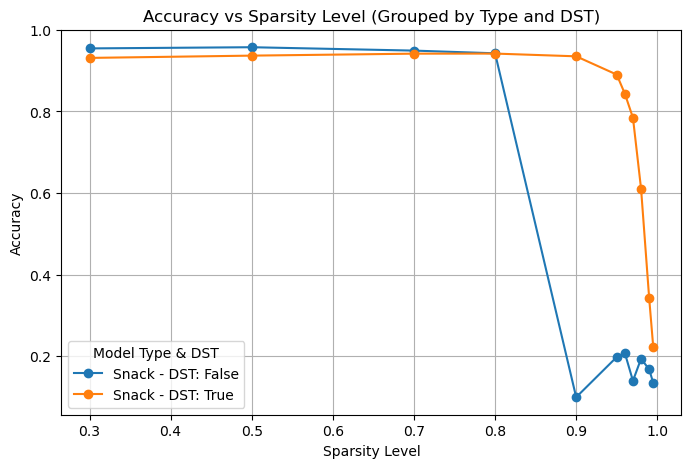

In [6]:
dfc = pd.read_csv("log_mnist.csv")
# print(df.to_markdown())
display(dfc.head())
# Plot
df = dfc[dfc.Type != "Dense"]
# Group by Type and DST, then compute the mean accuracy per sparsity level
df_grouped = df.groupby(["Type", "DST or Static", "sparsity_level"]).mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))

for (type_, dst), sub_df in df_grouped.groupby(["Type", "DST or Static"]):
    plt.plot(sub_df["sparsity_level"], sub_df["acc"], marker="o", linestyle="-", label=f"{type_} - DST: {dst}")

# Labels and Title
plt.xlabel("Sparsity Level")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Sparsity Level (Grouped by Type and DST)")
plt.legend(title="Model Type & DST")
plt.grid(True)

# Show plot
plt.show()

In [43]:
%pwd

'/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/DST'

In [48]:
import pandas as pd 



,isSparse,batch_size,dense_level,cuda_elapsed_time,total_params,energy_spent_per_second,sparsity_level,rep,energy_spent,average_power_used,average_utilization,average_memory_used,cuda_OOM,Type
0,Dense+Mask,1,10x10000,109.495293,210000,0.000009,0.90,0,0.001012,36.424500,0.0,717.750,False,Dense+Mask
1,Dense (Only),1,10x10000,33.723392,110000,0.000016,0.90,0,0.000551,39.702000,2.0,736.750,False,Dense (Only)
2,Dense+Mask,1,10x10000,36.292606,210000,0.000016,0.95,0,0.000582,41.910000,2.0,736.750,False,Dense+Mask
3,Dense (Only),1,10x10000,33.529858,110000,0.000018,0.95,0,0.000613,44.132000,4.0,736.750,False,Dense (Only)
4,Dense+Mask,1,10x10000,36.100098,210000,0.000018,0.99,0,0.000657,47.334000,2.0,736.750,False,Dense+Mask
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,Snack,2,45000x10000,436.937500,67510000,0.000005,0.95,0,0.002293,55.033667,10.0,2538.875,NaN,Snack
563,Snack,4,45000x10000,729.645264,67510000,0.000004,0.95,0,0.003057,55.018500,11.0,2540.875,NaN,Snack
564,Snack,1,45000x10000,62.644222,13510000,0.000012,0.99,0,0.000764,55.016000,0.0,2540.875,NaN,Snack
565,Snack,2,45000x10000,92.662109,13510000,0.000007,0.99,0,0.000654,47.098000,0.0,2540.875,NaN,Snack


In [6]:
df = pd.read_csv("../DST/log-aug-3-highsparsity.csv")
if "isSparse" in df.columns:
    df["Type"] = df["isSparse"]
df["input_size"] = df["dense_level"].map(lambda x: int(x.split("x")[0]))
df = df[df.batch_size == 2]
dfc = df[["Type", "input_size", "average_memory_used", "sparsity_level"]].groupby(["Type", "sparsity_level", "input_size"]).mean()
dfc = dfc.reset_index()
dfc[dfc.Type=="Dense (Only)"]

,Type,sparsity_level,input_size,average_memory_used
0,Dense (Only),0.90,2500,1726.937500
1,Dense (Only),0.90,5000,2462.812500
2,Dense (Only),0.90,7500,3612.750000
3,Dense (Only),0.90,10000,3916.083333
4,Dense (Only),0.90,12500,5512.750000
5,Dense (Only),0.90,15000,7620.750000
6,Dense (Only),0.90,17500,NaN
7,Dense (Only),0.90,20000,NaN
8,Dense (Only),0.90,25000,NaN
9,Dense (Only),0.90,30000,NaN


MEMORY USAGE COMPARISON: LINE PLOT SUMMARY
Snack (27, 4)

SNACK:
----------------------------------------
  Sparsity 0.9: Max input size = 25,000, Max memory = 1928.9 MB
  Sparsity 0.95: Max input size = 25,000, Max memory = 1294.9 MB
  Sparsity 0.99: Max input size = 25,000, Max memory = 890.9 MB
Dense (Only) (17, 4)

DENSE (ONLY):
----------------------------------------
  Sparsity 0.9: Max input size = 15,000, Max memory = 7620.8 MB
  Sparsity 0.95: Max input size = 15,000, Max memory = 7600.8 MB
  Sparsity 0.99: Max input size = 12,500, Max memory = 5513.4 MB
Dense+Mask (17, 4)

DENSE+MASK:
----------------------------------------
  Sparsity 0.9: Max input size = 12,500, Max memory = 5035.4 MB
  Sparsity 0.95: Max input size = 15,000, Max memory = 7002.8 MB
  Sparsity 0.99: Max input size = 15,000, Max memory = 7046.8 MB


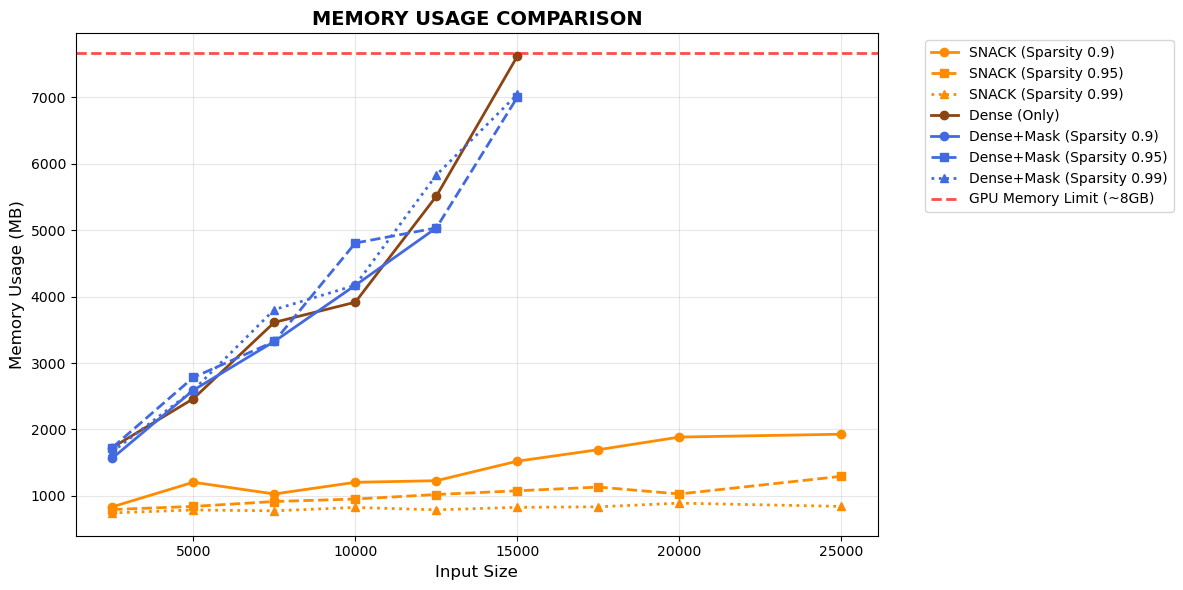

In [9]:
# Extract input size from dense_level

df = dfc
# Filter out OOM entries and get only successful runs
successful = df[(~df['average_memory_used'].isna()) & (df.input_size <= 25000)].copy()

# Create the plot
plt.figure(figsize=(12, 6))

# Color scheme for categories
colors = {
    'SNACK': '#FF8C00',  # Orange
    'Dense (Only)': '#8B4513',  # Brown
    'Dense+Mask': '#4169E1'  # Blue
}

# Line styles for sparsity levels
line_styles = {
    0.9: 'solid',
    0.95: 'dashed', 
    0.99: 'dotted'
}
markers = {
    0.9: 'o',
    0.95: 's', 
    0.99: '^'
}
# Plot lines for each category and sparsity combination
for category in ['Snack', 'Dense (Only)', 'Dense+Mask']:
    category_data = successful[successful['Type'] == category]
    
    for sparsity in [0.9, 0.95, 0.99]:
        sparsity_data = category_data[category_data['sparsity_level'] == sparsity]
        
        if not sparsity_data.empty:
            # Sort by input size for proper line plotting
            if "Only" in category and sparsity > 0.9:
                continue
            sparsity_data = sparsity_data.sort_values('input_size')
            category = category if category != "Snack" else "SNACK"
            plt.plot(sparsity_data['input_size'], sparsity_data['average_memory_used'],
                    color=colors[category], 
                    linestyle=line_styles[sparsity],
                    linewidth=2,
                    marker=markers[sparsity],
                    markersize=6,
                    label=f'{category} (Sparsity {sparsity})' if 'Only' not in category else category)

# Add memory limit line
memory_limit = 7672  # MB
plt.axhline(y=memory_limit, color='red', linestyle='--', alpha=0.7, 
           label='GPU Memory Limit (~8GB)', linewidth=2)

plt.xlabel('Input Size', fontsize=12)
plt.ylabel('Memory Usage (MB)', fontsize=12)
plt.title('MEMORY USAGE COMPARISON', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

# Set x-axis to show input sizes nicely
# plt.xscale('log')
# plt.yscale('log')

plt.tight_layout()
plt.savefig('../figures/memory_usage_lines.pdf', dpi=300, bbox_inches='tight')

# Print summary statistics
print("=" * 80)
print("MEMORY USAGE COMPARISON: LINE PLOT SUMMARY")
print("=" * 80)

for category in ['Snack', 'Dense (Only)', 'Dense+Mask']:
    category_data = successful[successful['Type'] == category]
    print(category, category_data.shape)
    print(f"\n{category.upper()}:")
    print("-" * 40)
    
    for sparsity in [0.9,0.95, 0.99]:
        sparsity_data = category_data[category_data['sparsity_level'] == sparsity]
        
        if not sparsity_data.empty:
            max_input = sparsity_data['input_size'].max()
            max_memory = sparsity_data['average_memory_used'].max()
            print(f"  Sparsity {sparsity}: Max input size = {max_input:,}, Max memory = {max_memory:.1f} MB")

In [93]:
dfc[(dfc.Type == "Snack") & (dfc.sparsity_level == 0.9)]

,Type,sparsity_level,input_size,average_memory_used
126,Snack,0.9,10,736.7500
127,Snack,0.9,100,738.7500
128,Snack,0.9,1000,794.7500
129,Snack,0.9,2500,1028.9375
130,Snack,0.9,5000,966.9375
131,Snack,0.9,7500,1112.7500
132,Snack,0.9,10000,1028.7500
133,Snack,0.9,12500,4370.7500
134,Snack,0.9,15000,1308.7500
135,Snack,0.9,17500,1402.7500


In [86]:
dfc[(dfc.Type == "Dense+Mask") & (dfc.sparsity_level == 0.95)]

,Type,sparsity_level,input_size,average_memory_used
84,Dense+Mask,0.95,10,737.416667
85,Dense+Mask,0.95,100,781.416667
86,Dense+Mask,0.95,1000,1121.416667
87,Dense+Mask,0.95,2500,1440.895833
88,Dense+Mask,0.95,5000,2592.937500
89,Dense+Mask,0.95,7500,3327.895833
90,Dense+Mask,0.95,10000,4682.750000
91,Dense+Mask,0.95,12500,4878.083333
92,Dense+Mask,0.95,15000,4792.750000
93,Dense+Mask,0.95,17500,4742.750000
